## AF with count of number for source and target

## AF with Percentage Conf

## =========================================

Using device: cuda
IMPROVED AF (Adversarial Domain Adaptation) MODEL EVALUATION
Improvements:
  ✓ Deeper architecture (4 layers in feature extractor)
  ✓ Larger embedding size (1024 instead of 512)
  ✓ LeakyReLU activation
  ✓ Label smoothing (0.1)
  ✓ Learning rate scheduling
  ✓ Early stopping with model checkpointing
  ✓ Larger batch size (64)
  ✓ More epochs (200)

[1] Loading oversampled data...
Class distribution in training data: [936 936 936 936 936 936]
Input dimension: 100

[2] Training improved AF base model...

TRAINING IMPROVED AF BASE MODEL
  Input dimension: 100
  Number of classes: 6

Training improved AF model...
  Model initialized: input_dim=100, num_classes=6
  Training: 4774 samples, Validation: 842 samples
  batch_size=64, epochs=200
  Epoch   1: Class Loss=1.7964, Domain Comb=0.7153, Domain Disc=0.7142, Val Acc=0.3563
  Epoch  20: Class Loss=1.1638, Domain Comb=0.6982, Domain Disc=0.7007, Val Acc=0.6330
  Epoch  40: Class Loss=1.0389, Domain Comb=0.6967, Domain D

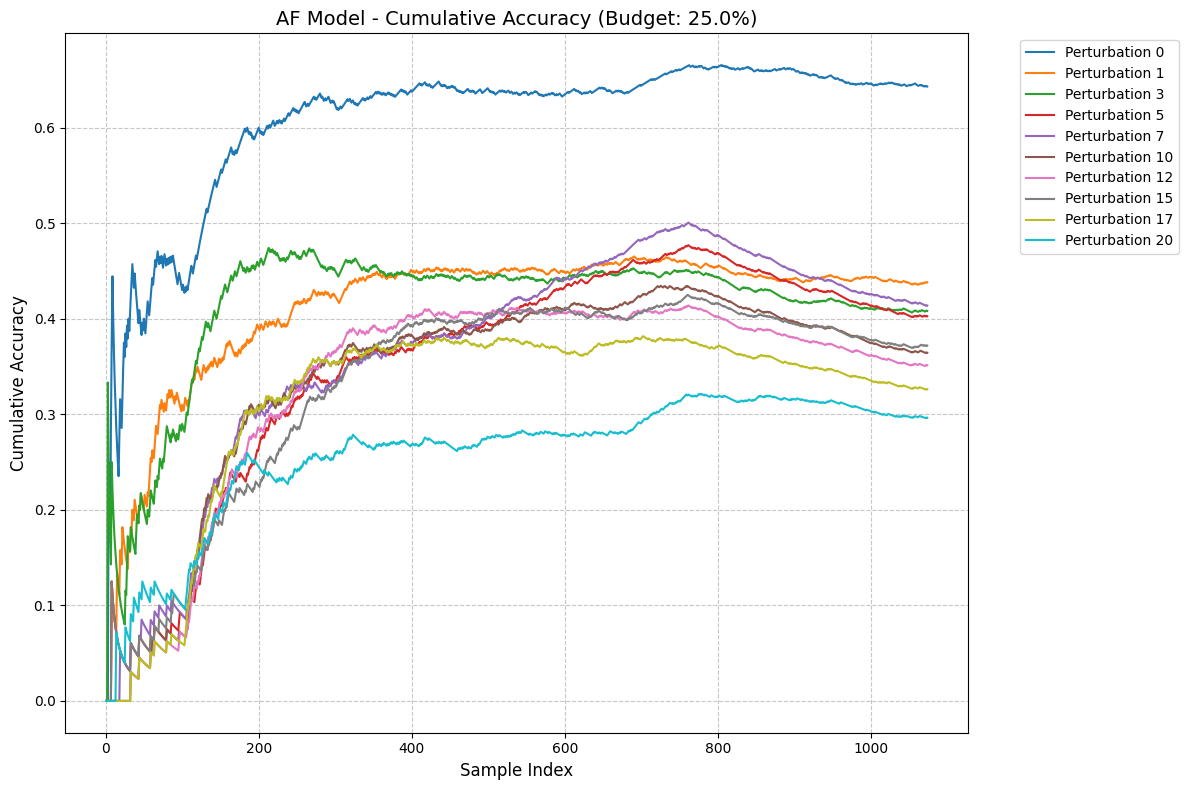

Plot saved to 'Results/AF_improved_cumulative_accuracy_budget_25.png'

EVALUATION COMPLETE


In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import random
from collections import deque
import os
import glob
import copy
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ==================== AF MODEL DEFINITION (بهبود یافته) ====================

class AFFeatureExtractor(nn.Module):
    """
    مدل AF بهبود یافته با معماری عمیق‌تر و تکنیک‌های regularization پیشرفته
    """
    def __init__(self, input_dim, num_classes, embedding_size=1024, hidden_dims=[512, 256, 128]):
        super().__init__()
        
        self.input_dim = input_dim
        self.embedding_size = embedding_size
        
        # ========== Feature Extractor ==========
        feature_layers = []
        prev_dim = input_dim
        
        for i, h_dim in enumerate(hidden_dims):
            feature_layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.LeakyReLU(0.2),
                nn.Dropout(0.2)
            ])
            prev_dim = h_dim
        
        self.projection = nn.Linear(prev_dim, embedding_size)
        self.embedding_bn = nn.BatchNorm1d(embedding_size)
        self.feature_extractor = nn.Sequential(*feature_layers)
        
        # ========== Classifier ==========
        self.classifier = nn.Sequential(
            nn.Linear(embedding_size, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
        
        # ========== Discriminator ==========
        self.discriminator = nn.Sequential(
            nn.Linear(embedding_size, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
        
        self.classifier_params = list(self.classifier.parameters())
        self.discriminator_params = list(self.discriminator.parameters())
        self.feature_params = list(self.feature_extractor.parameters()) + list(self.projection.parameters()) + list(self.embedding_bn.parameters())
        
        self.lr_classifier = 5e-4
        self.lr_discriminator = 1e-4
        self.lr_combined = 5e-5
        
        self.class_loss_weight = 5.0
        self.dis_loss_weight = 3.0
    
    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        features = self.projection(features)
        features = self.embedding_bn(features)
        class_output = self.classifier(features)
        class_output = nn.functional.softmax(class_output, dim=1)
        
        if return_features:
            return class_output, features
        return class_output
    
    def forward_with_domain(self, x):
        features = self.feature_extractor(x)
        features = self.projection(features)
        features = self.embedding_bn(features)
        class_output = self.classifier(features)
        domain_output = torch.sigmoid(self.discriminator(features))
        return class_output, domain_output
    
    def predict(self, x, device='cpu'):
        self.eval()
        with torch.no_grad():
            if len(x.shape) == 1:
                x_tensor = torch.FloatTensor(x).unsqueeze(0).to(device)
            else:
                x_tensor = torch.FloatTensor(x).to(device)
            class_output = self.forward(x_tensor)
            pred = torch.argmax(class_output, dim=1).cpu().numpy()
            if len(pred) == 1:
                return pred[0]
            return pred
    
    def partial_fit_batch(self, X_source, y_source, X_target, device='cpu', 
                          class_loss_weight=5.0, dis_loss_weight=3.0):
        self.train()
        
        X_s = torch.FloatTensor(X_source).to(device)
        y_s = torch.LongTensor(y_source).to(device)
        X_t = torch.FloatTensor(X_target).to(device)
        
        batch_size = min(X_s.size(0), X_t.size(0))
        X_s = X_s[:batch_size]
        y_s = y_s[:batch_size]
        X_t = X_t[:batch_size]
        
        X_combined = torch.cat([X_s, X_t], dim=0)
        
        disc_weights = {k: v.clone() for k, v in self.discriminator.state_dict().items()}
        
        # آموزش combined model
        opt_combined = optim.AdamW(self.feature_params + self.classifier_params, 
                                   lr=self.lr_combined, betas=(0.5, 0.999), weight_decay=1e-4)
        opt_combined.zero_grad()
        
        class_output, domain_output = self.forward_with_domain(X_combined)
        
        class_loss = nn.functional.cross_entropy(class_output[:batch_size], y_s, label_smoothing=0.1)
        
        domain_labels_combined = torch.cat([
            torch.ones(batch_size, dtype=torch.float32).to(device),
            torch.zeros(batch_size, dtype=torch.float32).to(device)
        ]).unsqueeze(1)
        domain_loss_combined = nn.functional.binary_cross_entropy(domain_output, domain_labels_combined)
        
        total_loss_combined = class_loss_weight * class_loss - dis_loss_weight * domain_loss_combined
        total_loss_combined.backward()
        torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
        opt_combined.step()
        
        self.discriminator.load_state_dict(disc_weights)
        
        # آموزش discriminator
        opt_discriminator = optim.AdamW(self.discriminator_params, lr=self.lr_discriminator,
                                        betas=(0.5, 0.999), weight_decay=1e-4)
        opt_discriminator.zero_grad()
        
        with torch.no_grad():
            features_s = self.feature_extractor(X_s)
            features_s = self.projection(features_s)
            features_s = self.embedding_bn(features_s)
            
            features_t = self.feature_extractor(X_t)
            features_t = self.projection(features_t)
            features_t = self.embedding_bn(features_t)
        
        features_combined = torch.cat([features_s, features_t], dim=0)
        domain_output_new = torch.sigmoid(self.discriminator(features_combined))
        
        domain_labels_disc = torch.cat([
            torch.zeros(batch_size, dtype=torch.float32).to(device),
            torch.ones(batch_size, dtype=torch.float32).to(device)
        ]).unsqueeze(1)
        domain_loss_disc = nn.functional.binary_cross_entropy(domain_output_new, domain_labels_disc)
        domain_loss_disc.backward()
        torch.nn.utils.clip_grad_norm_(self.discriminator_params, max_norm=1.0)
        opt_discriminator.step()
        
        return {
            'class_loss': class_loss.item(),
            'domain_loss_combined': domain_loss_combined.item(),
            'domain_loss_disc': domain_loss_disc.item()
        }


class AFClassifier:
    """
    Wrapper کلاس AF بهبود یافته
    """
    def __init__(self, input_dim=None, num_classes=None, embedding_size=1024, 
                 hidden_dims=[512, 256, 128], seed=42, 
                 class_loss_weight=5.0, dis_loss_weight=3.0):
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.embedding_size = embedding_size
        self.hidden_dims = hidden_dims
        self.seed = seed
        self.class_loss_weight = class_loss_weight
        self.dis_loss_weight = dis_loss_weight
        self.model = None
        self.device = device
        self.is_fitted = False
        
        self.buffer_X = []
        self.buffer_y = []
        self.buffer_X_target = []
    
    def _initialize_model(self):
        if self.input_dim is None or self.num_classes is None:
            raise ValueError("input_dim and num_classes must be set")
        
        torch.manual_seed(self.seed)
        np.random.seed(self.seed)
        random.seed(self.seed)
        
        self.model = AFFeatureExtractor(
            input_dim=self.input_dim,
            num_classes=self.num_classes,
            embedding_size=self.embedding_size,
            hidden_dims=self.hidden_dims
        ).to(self.device)
        self.is_fitted = True
        
        print(f"  Model initialized: input_dim={self.input_dim}, num_classes={self.num_classes}")
    
    def learn_one(self, x, y):
        if not self.is_fitted:
            self.input_dim = len(x)
            self.num_classes = max(y + 1, 2)
            self._initialize_model()
        
        if isinstance(x, dict):
            x = np.array([x[i] for i in range(len(x))])
        
        self.buffer_X.append(x)
        self.buffer_y.append(y)
        self.buffer_X_target.append(x)
        
        if len(self.buffer_X) >= 64:
            X_batch = np.array(self.buffer_X)
            y_batch = np.array(self.buffer_y)
            X_target_batch = np.array(self.buffer_X_target)
            
            _ = self.model.partial_fit_batch(
                X_batch, y_batch, X_target_batch, 
                device=self.device,
                class_loss_weight=self.class_loss_weight,
                dis_loss_weight=self.dis_loss_weight
            )
            
            self.buffer_X = []
            self.buffer_y = []
            self.buffer_X_target = []
        
        return self
    
    def predict_one(self, x):
        if not self.is_fitted:
            return 0
        
        if isinstance(x, dict):
            x = np.array([x[i] for i in range(len(x))])
        
        return self.model.predict(x, device=self.device)
    
    def train_batch_mode(self, X_source, y_source, X_target, n_epochs=200, batch_size=64, 
                         lr_schedule=True, early_stopping=True, patience=30):
        if not self.is_fitted:
            self.input_dim = X_source.shape[1]
            self.num_classes = len(np.unique(y_source))
            self._initialize_model()
        
        n_samples = len(X_source)
        
        val_size = int(0.15 * n_samples)
        indices = np.random.permutation(n_samples)
        train_indices = indices[val_size:]
        val_indices = indices[:val_size]
        
        X_train = X_source[train_indices]
        y_train = y_source[train_indices]
        X_val = X_source[val_indices]
        y_val = y_source[val_indices]
        
        print(f"  Training: {len(X_train)} samples, Validation: {len(X_val)} samples")
        print(f"  batch_size={batch_size}, epochs={n_epochs}")
        
        best_val_acc = 0
        epochs_no_improve = 0
        best_model_state = None
        
        for epoch in range(n_epochs):
            indices = np.random.permutation(len(X_train))
            total_class_loss = 0
            total_domain_loss_combined = 0
            total_domain_loss_disc = 0
            n_batches = 0
            
            for i in range(0, len(X_train), batch_size):
                batch_indices = indices[i:i+batch_size]
                X_s_batch = X_train[batch_indices]
                y_s_batch = y_train[batch_indices]
                
                target_indices = np.random.choice(len(X_train), len(batch_indices), replace=False)
                X_t_batch = X_train[target_indices]
                
                losses = self.model.partial_fit_batch(
                    X_s_batch, y_s_batch, X_t_batch,
                    device=self.device,
                    class_loss_weight=self.class_loss_weight,
                    dis_loss_weight=self.dis_loss_weight
                )
                
                total_class_loss += losses['class_loss']
                total_domain_loss_combined += losses['domain_loss_combined']
                total_domain_loss_disc += losses['domain_loss_disc']
                n_batches += 1
            
            self.model.eval()
            with torch.no_grad():
                X_val_tensor = torch.FloatTensor(X_val).to(self.device)
                val_output = self.model.forward(X_val_tensor)
                y_val_pred = torch.argmax(val_output, dim=1).cpu().numpy()
            val_acc = accuracy_score(y_val, y_val_pred)
            self.model.train()
            
            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    epochs_no_improve = 0
                    best_model_state = copy.deepcopy(self.model.state_dict())
                else:
                    epochs_no_improve += 1
                
                if epochs_no_improve >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    if best_model_state is not None:
                        self.model.load_state_dict(best_model_state)
                    break
            
            if (epoch + 1) % 20 == 0 or epoch == 0:
                print(f"  Epoch {epoch+1:3d}: Class Loss={total_class_loss/n_batches:.4f}, "
                      f"Domain Comb={total_domain_loss_combined/n_batches:.4f}, "
                      f"Domain Disc={total_domain_loss_disc/n_batches:.4f}, "
                      f"Val Acc={val_acc:.4f}")
            
            if lr_schedule and epoch == n_epochs // 2:
                self.model.lr_classifier *= 0.5
                self.model.lr_combined *= 0.5
                self.model.lr_discriminator *= 0.5
                print(f"  Learning rate reduced at epoch {epoch+1}")
        
        return self


# ==================== DATA LOADING FUNCTIONS ====================

def load_oversampled_data(dataset_path='Dataset'):
    try:
        train_df = pd.read_csv(f'{dataset_path}/oversampled_train_dataset.csv')
        val_df = pd.read_csv(f'{dataset_path}/oversampled_validation_dataset.csv')
        test_df = pd.read_csv(f'{dataset_path}/oversampled_test_dataset.csv')
        
        X_train = train_df.iloc[:, :-1].values
        y_train = train_df.iloc[:, -1].values
        X_val = val_df.iloc[:, :-1].values
        y_val = val_df.iloc[:, -1].values
        X_test = test_df.iloc[:, :-1].values
        y_test = test_df.iloc[:, -1].values
        
    except FileNotFoundError as e:
        print(f"Error: Dataset file not found: {e}")
        return None, None, None, None, None, None, None
    
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    y_val = label_encoder.transform(y_val)
    y_test = label_encoder.transform(y_test)
    num_classes = len(label_encoder.classes_)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    print(f"Class distribution in training data: {np.bincount(y_train)}")
    print(f"Input dimension: {X_train.shape[1]}")
    
    return X_train, y_train, X_val, y_val, X_test, y_test, label_encoder, scaler, num_classes


def load_burst_data(base_path='AdvBurst_FTSC-IAT', perturb_level=0):
    file_path = f'{base_path}/AdvBurstTrainedBurst_size_{perturb_level}_Step_2000.csv'
    
    if not os.path.exists(file_path):
        print(f"Warning: File {file_path} not found.")
        return None, None, None
    
    try:
        df = pd.read_csv(file_path)
        X = df.iloc[:, :-1].values
        y = df.iloc[:, -1].values
        return X, y, df
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None, None


def train_base_model_af_improved(X_train, y_train, X_val, y_val, num_classes, input_dim):
    print(f"\n{'='*60}")
    print(f"TRAINING IMPROVED AF BASE MODEL")
    print(f"{'='*60}")
    print(f"  Input dimension: {input_dim}")
    print(f"  Number of classes: {num_classes}")
    
    model = AFClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
        embedding_size=1024,
        hidden_dims=[512, 256, 128],
        class_loss_weight=5.0,
        dis_loss_weight=3.0,
        seed=42
    )
    
    print("\nTraining improved AF model...")
    model.train_batch_mode(
        X_train, y_train, X_train, 
        n_epochs=200,
        batch_size=64,
        lr_schedule=True,
        early_stopping=True,
        patience=30
    )
    
    model.model.eval()
    with torch.no_grad():
        X_val_tensor = torch.FloatTensor(X_val).to(model.device)
        val_output = model.model.forward(X_val_tensor)
        y_val_pred = torch.argmax(val_output, dim=1).cpu().numpy()
    
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"IMPROVED BASE MODEL VALIDATION RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy:  {val_accuracy:.4f} ({val_accuracy*100:.1f}%)")
    print(f"  Precision: {val_precision:.4f}")
    print(f"  Recall:    {val_recall:.4f}")
    print(f"  F1 Score:  {val_f1:.4f}")
    
    return model


def test_af_online_with_budget(base_model, X_test, y_test, perturb_level, update_budget=1.0, 
                                max_test_samples=None, verbose=True):
    model = AFClassifier(
        input_dim=base_model.input_dim,
        num_classes=base_model.num_classes,
        embedding_size=1024,
        hidden_dims=[512, 256, 128],
        class_loss_weight=5.0,
        dis_loss_weight=3.0,
        seed=42
    )
    
    model.model = copy.deepcopy(base_model.model)
    model.is_fitted = True
    model.device = base_model.device
    
    n_samples = min(len(X_test), max_test_samples) if max_test_samples else len(X_test)
    X_test = X_test[:n_samples]
    y_test = y_test[:n_samples]
    
    n_updates_allowed = int(n_samples * update_budget)
    
    y_pred = []
    y_true_list = []
    updates_done = 0
    sample_accuracies = []
    
    if verbose:
        print(f"\n--- Testing Perturbation Level {perturb_level} (Budget: {update_budget*100}%) ---")
    
    for i, (xi, yi) in enumerate(zip(X_test, y_test)):
        xi_dict = {j: float(x) for j, x in enumerate(xi)}
        
        pred = model.predict_one(xi_dict)
        y_pred.append(pred)
        y_true_list.append(yi)
        
        if updates_done < n_updates_allowed:
            model.learn_one(xi_dict, yi)
            updates_done += 1
        
        current_acc = accuracy_score(y_true_list, y_pred)
        sample_accuracies.append(current_acc)
        
        if verbose and (i + 1) % 500 == 0 and i > 0:
            print(f"  Sample {i+1}: Updates={updates_done}, Recent Acc={current_acc:.4f}")
    
    accuracy = accuracy_score(y_true_list, y_pred)
    precision = precision_score(y_true_list, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true_list, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true_list, y_pred, average='weighted', zero_division=0)
    
    if verbose:
        print(f"  Final - Acc: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    return {
        'Perturbation Level': perturb_level,
        'Update Budget %': update_budget * 100,
        'Total Samples': n_samples,
        'Updates Done': updates_done,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Sample Accuracies': sample_accuracies
    }


def test_af_multiple_perturbations(base_model, scaler, label_encoder, burst_base_path='AdvBurst_FTSC-IAT',
                                    test_perturb_levels=[0, 1, 3, 5, 7, 10, 12, 15, 17, 20],
                                    update_budget=0.2, max_test_samples=1073):
    all_results = []
    all_sample_accuracies = {}
    
    print("\n" + "="*80)
    print("AF MODEL - TESTING ON BURST DATASET WITH DIFFERENT PERTURBATION LEVELS")
    print(f"Update Budget: {update_budget*100}%")
    print("="*80)
    
    for perturb_level in test_perturb_levels:
        X_burst, y_burst, _ = load_burst_data(burst_base_path, perturb_level)
        
        if X_burst is None:
            print(f"Skipping perturbation level {perturb_level} - data not found")
            continue
        
        try:
            X_scaled = scaler.transform(X_burst)
            y_encoded = label_encoder.transform(y_burst)
        except ValueError as e:
            print(f"Error encoding labels for level {perturb_level}: {e}")
            continue
        
        result = test_af_online_with_budget(
            base_model, X_scaled, y_encoded, perturb_level,
            update_budget=update_budget,
            max_test_samples=max_test_samples,
            verbose=True
        )
        all_results.append(result)
        all_sample_accuracies[perturb_level] = result['Sample Accuracies']
    
    # ذخیره نتایج
    os.makedirs('Results', exist_ok=True)
    
    df_results = pd.DataFrame([{k: v for k, v in r.items() if k != 'Sample Accuracies'} 
                                for r in all_results])
    df_results.to_csv(f'Results/AF_improved_Burst_results_budget_{int(update_budget*100)}.csv', index=False)
    
    print("\n" + "="*60)
    print("FINAL RESULTS SUMMARY (4 Metrics)")
    print("="*60)
    print(df_results[['Perturbation Level', 'Updates Done', 'Accuracy', 'Precision', 'Recall', 'F1 Score']].to_string(index=False))
    
    # رسم نمودار cumulative accuracy (مشابه قبل)
    if all_sample_accuracies:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 8))
        for perturb_level, accuracies in all_sample_accuracies.items():
            plt.plot(range(1, len(accuracies) + 1), accuracies, 
                     label=f'Perturbation {perturb_level}', linewidth=1.5)
        plt.xlabel('Sample Index', fontsize=12)
        plt.ylabel('Cumulative Accuracy', fontsize=12)
        plt.title(f'AF Model - Cumulative Accuracy (Budget: {update_budget*100}%)', fontsize=14)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig(f'Results/AF_improved_cumulative_accuracy_budget_{int(update_budget*100)}.png', dpi=300)
        plt.show()
        print(f"Plot saved to 'Results/AF_improved_cumulative_accuracy_budget_{int(update_budget*100)}.png'")
    
    return df_results


def test_af_multiple_budgets(base_model, scaler, label_encoder, burst_base_path='AdvBurst_FTSC-IAT',
                              test_perturb_levels=[0, 1, 3, 5, 7, 10, 12, 15, 17, 20],
                              budgets=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
                              max_test_samples=1073):
    all_results = []
    
    print("\n" + "="*80)
    print("AF MODEL - MULTIPLE BUDGETS TEST ON BURST DATASET")
    print("="*80)
    
    for budget in budgets:
        print(f"\n{'='*60}")
        print(f"BUDGET: {budget*100}%")
        print('='*60)
        
        for perturb_level in test_perturb_levels:
            X_burst, y_burst, _ = load_burst_data(burst_base_path, perturb_level)
            
            if X_burst is None:
                continue
            
            try:
                X_scaled = scaler.transform(X_burst)
                y_encoded = label_encoder.transform(y_burst)
            except ValueError as e:
                print(f"Error encoding labels for level {perturb_level}: {e}")
                continue
            
            result = test_af_online_with_budget(
                base_model, X_scaled, y_encoded, perturb_level,
                update_budget=budget,
                max_test_samples=max_test_samples,
                verbose=False
            )
            if 'Sample Accuracies' in result:
                del result['Sample Accuracies']
            all_results.append(result)
            print(f"  Level {perturb_level:3d}: Acc={result['Accuracy']:.4f}, "
                  f"Prec={result['Precision']:.4f}, Rec={result['Recall']:.4f}, F1={result['F1 Score']:.4f}")
    
    df_all = pd.DataFrame(all_results)
    os.makedirs('Results', exist_ok=True)
    df_all.to_csv('Results/AF_improved_Burst_all_budgets.csv', index=False)
    
    # خلاصه Accuracy
    summary_acc = df_all.pivot_table(
        index='Perturbation Level',
        columns='Update Budget %',
        values='Accuracy',
        aggfunc='first'
    )
    
    # خلاصه F1
    summary_f1 = df_all.pivot_table(
        index='Perturbation Level',
        columns='Update Budget %',
        values='F1 Score',
        aggfunc='first'
    )
    
    print("\n" + "="*60)
    print("ACCURACY SUMMARY TABLE")
    print("="*60)
    print(summary_acc.round(4))
    
    print("\n" + "="*60)
    print("F1 SCORE SUMMARY TABLE")
    print("="*60)
    print(summary_f1.round(4))
    
    summary_acc.to_csv('Results/AF_improved_Burst_accuracy_summary.csv')
    summary_f1.to_csv('Results/AF_improved_Burst_f1_summary.csv')
    
    # رسم نمودار مقایسه بودجه‌ها (مشابه قبل)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 8))
    for budget in budgets:
        budget_data = df_all[df_all['Update Budget %'] == budget * 100]
        if not budget_data.empty:
            plt.plot(budget_data['Perturbation Level'], budget_data['Accuracy'], 
                     'o-', linewidth=2, markersize=6, label=f'Budget {budget*100}%')
    plt.xlabel('Perturbation Level', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('AF Model Performance Across Different Budgets', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig('Results/AF_improved_budgets_comparison.png', dpi=300)
    plt.show()
    
    return df_all


def main():
    """اجرای اصلی با مدل AF بهبود یافته و نمودارهای مشابه قبل"""
    
    OVERSAMPLED_DATA_PATH = '../Dataset'
    BURST_DATA_PATH = '../AdvBurst_FTSC-IAT'
    TEST_PERTURB_LEVELS = [0, 1, 3, 5, 7, 10, 12, 15, 17, 20]
    UPDATE_BUDGET = 0.25
    MAX_TEST_SAMPLES = 1073
    
    print("="*80)
    print("IMPROVED AF (Adversarial Domain Adaptation) MODEL EVALUATION")
    print("="*80)
    print("Improvements:")
    print("  ✓ Deeper architecture (4 layers in feature extractor)")
    print("  ✓ Larger embedding size (1024 instead of 512)")
    print("  ✓ LeakyReLU activation")
    print("  ✓ Label smoothing (0.1)")
    print("  ✓ Learning rate scheduling")
    print("  ✓ Early stopping with model checkpointing")
    print("  ✓ Larger batch size (64)")
    print("  ✓ More epochs (200)")
    print("="*80)
    
    # بارگذاری داده
    print("\n[1] Loading oversampled data...")
    data = load_oversampled_data(OVERSAMPLED_DATA_PATH)
    
    if data[0] is None:
        print("Failed to load oversampled data. Exiting.")
        return
    
    X_train, y_train, X_val, y_val, X_test, y_test, label_encoder, scaler, num_classes = data
    input_dim = X_train.shape[1]
    
    # آموزش مدل پایه بهبود یافته
    print("\n[2] Training improved AF base model...")
    base_model = train_base_model_af_improved(X_train, y_train, X_val, y_val, num_classes, input_dim)
    
    # ذخیره مدل
    os.makedirs('Models', exist_ok=True)
    torch.save({
        'model_state_dict': base_model.model.state_dict(),
        'input_dim': input_dim,
        'num_classes': num_classes,
        'embedding_size': 1024,
        'hidden_dims': [512, 256, 128]
    }, 'Models/AF_improved_base_model.pth')
    print("\nImproved AF model saved to 'Models/AF_improved_base_model.pth'")
    
    # تست روی داده‌های Burst با یک بودجه
    print("\n[3] Testing on Burst dataset with single budget...")
    results_single = test_af_multiple_perturbations(
        base_model, scaler, label_encoder,
        burst_base_path=BURST_DATA_PATH,
        test_perturb_levels=TEST_PERTURB_LEVELS,
        update_budget=UPDATE_BUDGET,
        max_test_samples=MAX_TEST_SAMPLES
    )
    
    
    print("\n" + "="*80)
    print("EVALUATION COMPLETE")
    print("="*80)


if __name__ == "__main__":
    import matplotlib.pyplot as plt
    main()

Using device: cuda
AF MODEL - CUMULATIVE ACCURACY EVALUATION ON BURST DATASET
Perturbation levels: [0, 1, 3, 5, 7, 10, 12, 15, 17, 20]
Update Budget: 25.0%

📋 CSV FILE FORMAT (11 ROWS TOTAL):
   - Row 1: Column headers (Sample Index, 1, 2, 3, ...)
   - Rows 2-11: Each row represents ONE perturbation level
   - Column 1: Perturbation level value
   - Columns 2-N: Cumulative accuracy after each sample
   Total rows in CSV: 11 = 11 rows

[1] Loading oversampled data...
Class distribution in training data: [936 936 936 936 936 936]
Input dimension: 100

[2] Training improved AF base model...

TRAINING IMPROVED AF BASE MODEL
  Input dimension: 100
  Number of classes: 6

Training improved AF model...
  Model initialized: input_dim=100, num_classes=6
  Training: 4774 samples, Validation: 842 samples
  batch_size=64, epochs=200
  Epoch   1: Class Loss=1.7964, Domain Comb=0.7153, Domain Disc=0.7142, Val Acc=0.3563
  Epoch  20: Class Loss=1.1638, Domain Comb=0.6982, Domain Disc=0.7007, Val Acc=

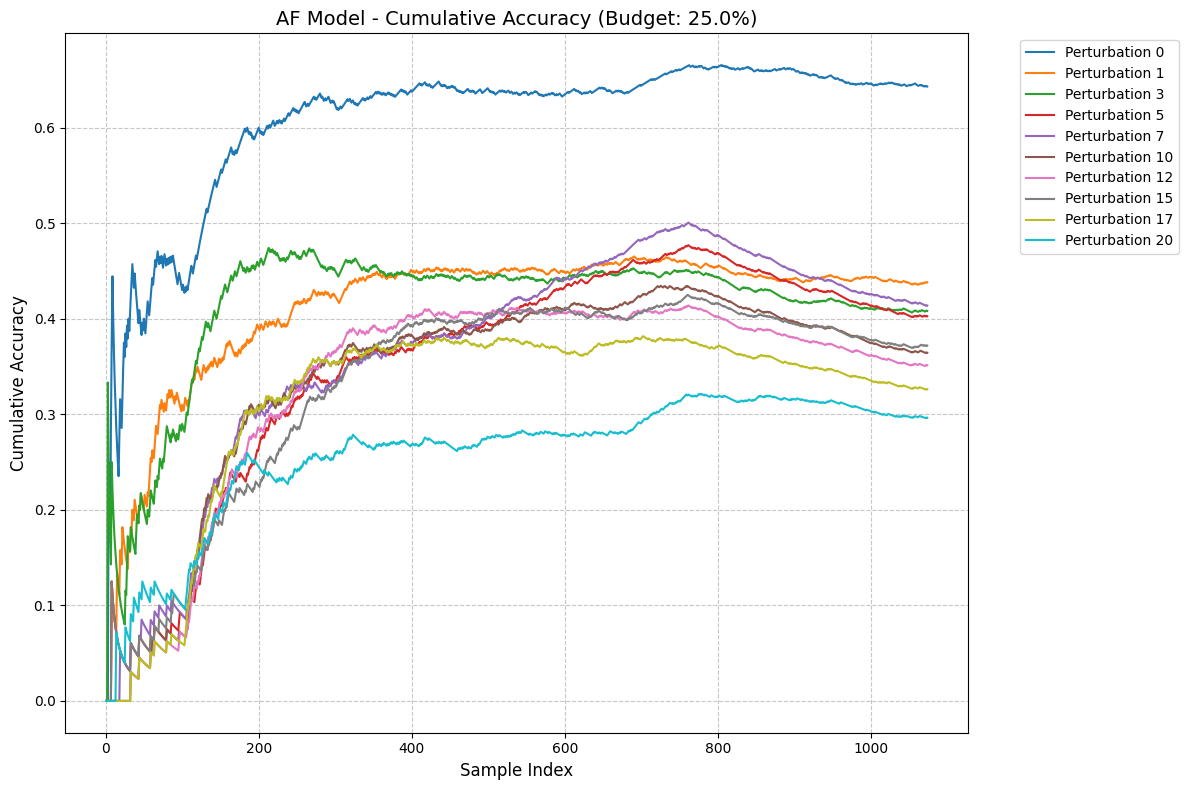

📊 Plot saved to: Results/AF_cumulative_accuracy_full_budget_25.png

💾 CSV saved to: Results/AF_cumulative_accuracy_full.csv

🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
PART 2: Processing FIRST 100 samples only
🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
AF MODEL - CREATING CUMULATIVE ACCURACY CSV FILE
Update Budget: 25.0%

📊 Processing perturbation levels:
------------------------------------------------------------

--- Perturbation Level 0 ---
  Using first 100 samples
  Computing cumulative accuracy for 100 samples...
  ✅ Done in 0.11s
  Final accuracy: 0.4400 (44.00%)

--- Perturbation Level 1 ---
  Using first 100 samples
  Computing cumulative accuracy for 100 samples...
  ✅ Done in 0.12s
  Final accuracy: 0.3100 (31.00%)

--- Perturbation Level 3 ---
  Using first 100 samples
  Computing cumulative accuracy for 100 samples...
  ✅ Done in 0.12s
  Final accuracy: 0.2900 (29.00%)

--- Perturbation Level 5 ---
  Using first 100 samples
  Computing cumulative accuracy for 100 samples...
 

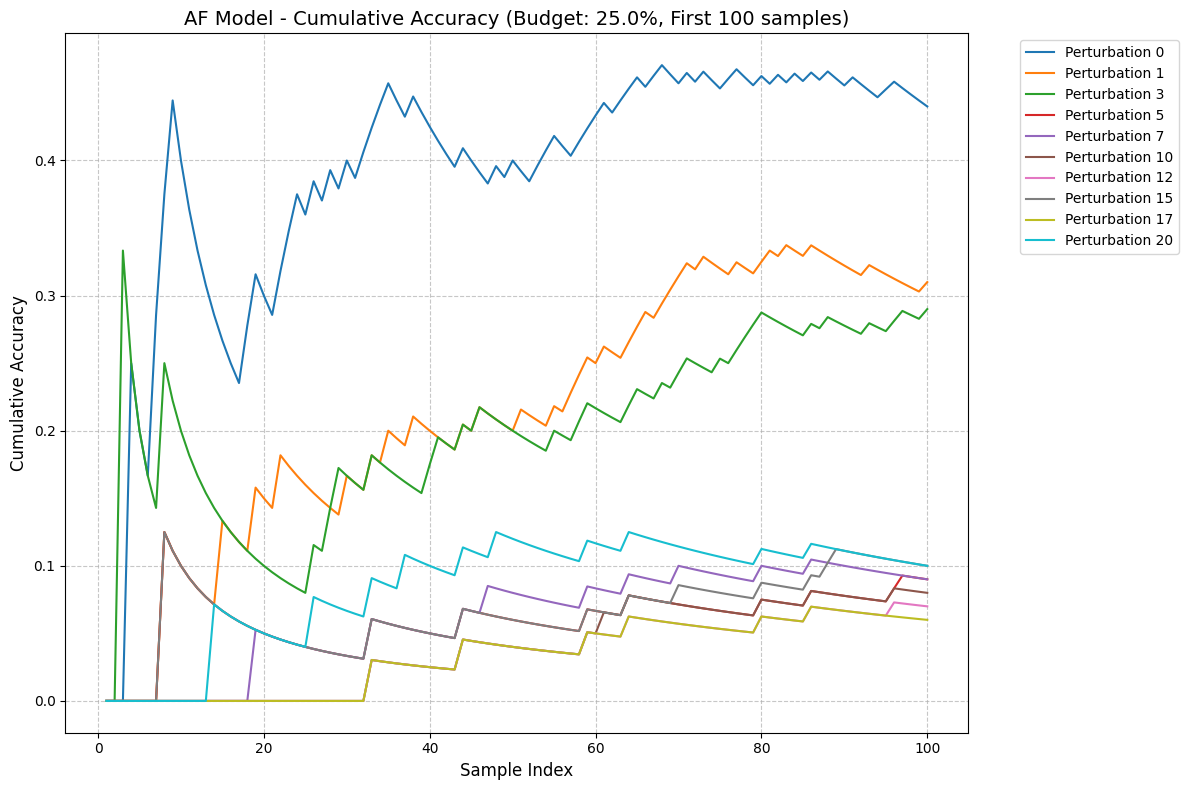

📊 Plot saved to: Results/AF_cumulative_accuracy_first_100_budget_25.png

💾 CSV saved to: Results/AF_cumulative_accuracy_first_100.csv

SUMMARY - FINAL CUMULATIVE ACCURACIES
 Perturbation Level Full Dataset Final Acc First 100 Final Acc
                  0                 0.6431              0.4400
                  1                 0.4380              0.3100
                  3                 0.4082              0.2900
                  5                 0.4026              0.0900
                  7                 0.4138              0.0900
                 10                 0.3644              0.0800
                 12                 0.3514              0.0700
                 15                 0.3719              0.1000
                 17                 0.3262              0.0600
                 20                 0.2964              0.1000

💾 Summary saved to: Results/AF_cumulative_accuracy_summary.csv

✅ AF EVALUATION COMPLETE

📁 Generated files:
  1. Results/AF_cumulati

In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import random
from collections import deque
import os
import glob
import copy
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# ==================== AF MODEL DEFINITION (بهبود یافته) ====================

class AFFeatureExtractor(nn.Module):
    """
    مدل AF بهبود یافته با معماری عمیق‌تر و تکنیک‌های regularization پیشرفته
    """
    def __init__(self, input_dim, num_classes, embedding_size=1024, hidden_dims=[512, 256, 128]):
        super().__init__()
        
        self.input_dim = input_dim
        self.embedding_size = embedding_size
        
        # ========== Feature Extractor ==========
        feature_layers = []
        prev_dim = input_dim
        
        for i, h_dim in enumerate(hidden_dims):
            feature_layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.LeakyReLU(0.2),
                nn.Dropout(0.2)
            ])
            prev_dim = h_dim
        
        self.projection = nn.Linear(prev_dim, embedding_size)
        self.embedding_bn = nn.BatchNorm1d(embedding_size)
        self.feature_extractor = nn.Sequential(*feature_layers)
        
        # ========== Classifier ==========
        self.classifier = nn.Sequential(
            nn.Linear(embedding_size, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
        
        # ========== Discriminator ==========
        self.discriminator = nn.Sequential(
            nn.Linear(embedding_size, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
        
        self.classifier_params = list(self.classifier.parameters())
        self.discriminator_params = list(self.discriminator.parameters())
        self.feature_params = list(self.feature_extractor.parameters()) + list(self.projection.parameters()) + list(self.embedding_bn.parameters())
        
        self.lr_classifier = 5e-4
        self.lr_discriminator = 1e-4
        self.lr_combined = 5e-5
        
        self.class_loss_weight = 5.0
        self.dis_loss_weight = 3.0
    
    def forward(self, x, return_features=False):
        features = self.feature_extractor(x)
        features = self.projection(features)
        features = self.embedding_bn(features)
        class_output = self.classifier(features)
        class_output = nn.functional.softmax(class_output, dim=1)
        
        if return_features:
            return class_output, features
        return class_output
    
    def forward_with_domain(self, x):
        features = self.feature_extractor(x)
        features = self.projection(features)
        features = self.embedding_bn(features)
        class_output = self.classifier(features)
        domain_output = torch.sigmoid(self.discriminator(features))
        return class_output, domain_output
    
    def predict(self, x, device='cpu'):
        self.eval()
        with torch.no_grad():
            if len(x.shape) == 1:
                x_tensor = torch.FloatTensor(x).unsqueeze(0).to(device)
            else:
                x_tensor = torch.FloatTensor(x).to(device)
            class_output = self.forward(x_tensor)
            pred = torch.argmax(class_output, dim=1).cpu().numpy()
            if len(pred) == 1:
                return pred[0]
            return pred
    
    def partial_fit_batch(self, X_source, y_source, X_target, device='cpu', 
                          class_loss_weight=5.0, dis_loss_weight=3.0):
        self.train()
        
        X_s = torch.FloatTensor(X_source).to(device)
        y_s = torch.LongTensor(y_source).to(device)
        X_t = torch.FloatTensor(X_target).to(device)
        
        batch_size = min(X_s.size(0), X_t.size(0))
        X_s = X_s[:batch_size]
        y_s = y_s[:batch_size]
        X_t = X_t[:batch_size]
        
        X_combined = torch.cat([X_s, X_t], dim=0)
        
        disc_weights = {k: v.clone() for k, v in self.discriminator.state_dict().items()}
        
        # آموزش combined model
        opt_combined = optim.AdamW(self.feature_params + self.classifier_params, 
                                   lr=self.lr_combined, betas=(0.5, 0.999), weight_decay=1e-4)
        opt_combined.zero_grad()
        
        class_output, domain_output = self.forward_with_domain(X_combined)
        
        class_loss = nn.functional.cross_entropy(class_output[:batch_size], y_s, label_smoothing=0.1)
        
        domain_labels_combined = torch.cat([
            torch.ones(batch_size, dtype=torch.float32).to(device),
            torch.zeros(batch_size, dtype=torch.float32).to(device)
        ]).unsqueeze(1)
        domain_loss_combined = nn.functional.binary_cross_entropy(domain_output, domain_labels_combined)
        
        total_loss_combined = class_loss_weight * class_loss - dis_loss_weight * domain_loss_combined
        total_loss_combined.backward()
        torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
        opt_combined.step()
        
        self.discriminator.load_state_dict(disc_weights)
        
        # آموزش discriminator
        opt_discriminator = optim.AdamW(self.discriminator_params, lr=self.lr_discriminator,
                                        betas=(0.5, 0.999), weight_decay=1e-4)
        opt_discriminator.zero_grad()
        
        with torch.no_grad():
            features_s = self.feature_extractor(X_s)
            features_s = self.projection(features_s)
            features_s = self.embedding_bn(features_s)
            
            features_t = self.feature_extractor(X_t)
            features_t = self.projection(features_t)
            features_t = self.embedding_bn(features_t)
        
        features_combined = torch.cat([features_s, features_t], dim=0)
        domain_output_new = torch.sigmoid(self.discriminator(features_combined))
        
        domain_labels_disc = torch.cat([
            torch.zeros(batch_size, dtype=torch.float32).to(device),
            torch.ones(batch_size, dtype=torch.float32).to(device)
        ]).unsqueeze(1)
        domain_loss_disc = nn.functional.binary_cross_entropy(domain_output_new, domain_labels_disc)
        domain_loss_disc.backward()
        torch.nn.utils.clip_grad_norm_(self.discriminator_params, max_norm=1.0)
        opt_discriminator.step()
        
        return {
            'class_loss': class_loss.item(),
            'domain_loss_combined': domain_loss_combined.item(),
            'domain_loss_disc': domain_loss_disc.item()
        }


class AFClassifier:
    """
    Wrapper کلاس AF بهبود یافته
    """
    def __init__(self, input_dim=None, num_classes=None, embedding_size=1024, 
                 hidden_dims=[512, 256, 128], seed=42, 
                 class_loss_weight=5.0, dis_loss_weight=3.0):
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.embedding_size = embedding_size
        self.hidden_dims = hidden_dims
        self.seed = seed
        self.class_loss_weight = class_loss_weight
        self.dis_loss_weight = dis_loss_weight
        self.model = None
        self.device = device
        self.is_fitted = False
        
        self.buffer_X = []
        self.buffer_y = []
        self.buffer_X_target = []
    
    def _initialize_model(self):
        if self.input_dim is None or self.num_classes is None:
            raise ValueError("input_dim and num_classes must be set")
        
        torch.manual_seed(self.seed)
        np.random.seed(self.seed)
        random.seed(self.seed)
        
        self.model = AFFeatureExtractor(
            input_dim=self.input_dim,
            num_classes=self.num_classes,
            embedding_size=self.embedding_size,
            hidden_dims=self.hidden_dims
        ).to(self.device)
        self.is_fitted = True
        
        print(f"  Model initialized: input_dim={self.input_dim}, num_classes={self.num_classes}")
    
    def learn_one(self, x, y):
        if not self.is_fitted:
            self.input_dim = len(x)
            self.num_classes = max(y + 1, 2)
            self._initialize_model()
        
        if isinstance(x, dict):
            x = np.array([x[i] for i in range(len(x))])
        
        self.buffer_X.append(x)
        self.buffer_y.append(y)
        self.buffer_X_target.append(x)
        
        if len(self.buffer_X) >= 64:
            X_batch = np.array(self.buffer_X)
            y_batch = np.array(self.buffer_y)
            X_target_batch = np.array(self.buffer_X_target)
            
            _ = self.model.partial_fit_batch(
                X_batch, y_batch, X_target_batch, 
                device=self.device,
                class_loss_weight=self.class_loss_weight,
                dis_loss_weight=self.dis_loss_weight
            )
            
            self.buffer_X = []
            self.buffer_y = []
            self.buffer_X_target = []
        
        return self
    
    def predict_one(self, x):
        if not self.is_fitted:
            return 0
        
        if isinstance(x, dict):
            x = np.array([x[i] for i in range(len(x))])
        
        return self.model.predict(x, device=self.device)
    
    def predict_with_cumulative_accuracy(self, X, y, update_budget=0.25):
        """
        پیش‌بینی نمونه به نمونه و محاسبه cumulative accuracy
        با بودجه مشخص برای به‌روزرسانی مدل
        
        خروجی: لیستی از accuracy های تجمعی بعد از هر نمونه
        """
        # ایجاد یک کپی از مدل برای تست آنلاین
        model = AFClassifier(
            input_dim=self.input_dim,
            num_classes=self.num_classes,
            embedding_size=self.embedding_size,
            hidden_dims=self.hidden_dims,
            class_loss_weight=self.class_loss_weight,
            dis_loss_weight=self.dis_loss_weight,
            seed=self.seed
        )
        
        model.model = copy.deepcopy(self.model)
        model.is_fitted = True
        model.device = self.device
        
        n_samples = len(X)
        n_updates_allowed = int(n_samples * update_budget)
        
        cumulative_accuracies = []
        correct_count = 0
        total_count = 0
        updates_done = 0
        
        for i, (xi, yi) in enumerate(zip(X, y)):
            xi_dict = {j: float(x) for j, x in enumerate(xi)}
            
            pred = model.predict_one(xi_dict)
            
            if pred == yi:
                correct_count += 1
            total_count += 1
            
            # به‌روزرسانی مدل با بودجه محدود
            if updates_done < n_updates_allowed:
                model.learn_one(xi_dict, yi)
                updates_done += 1
            
            current_acc = correct_count / total_count
            cumulative_accuracies.append(current_acc)
        
        return cumulative_accuracies
    
    def train_batch_mode(self, X_source, y_source, X_target, n_epochs=200, batch_size=64, 
                         lr_schedule=True, early_stopping=True, patience=30):
        if not self.is_fitted:
            self.input_dim = X_source.shape[1]
            self.num_classes = len(np.unique(y_source))
            self._initialize_model()
        
        n_samples = len(X_source)
        
        val_size = int(0.15 * n_samples)
        indices = np.random.permutation(n_samples)
        train_indices = indices[val_size:]
        val_indices = indices[:val_size]
        
        X_train = X_source[train_indices]
        y_train = y_source[train_indices]
        X_val = X_source[val_indices]
        y_val = y_source[val_indices]
        
        print(f"  Training: {len(X_train)} samples, Validation: {len(X_val)} samples")
        print(f"  batch_size={batch_size}, epochs={n_epochs}")
        
        best_val_acc = 0
        epochs_no_improve = 0
        best_model_state = None
        
        for epoch in range(n_epochs):
            indices = np.random.permutation(len(X_train))
            total_class_loss = 0
            total_domain_loss_combined = 0
            total_domain_loss_disc = 0
            n_batches = 0
            
            for i in range(0, len(X_train), batch_size):
                batch_indices = indices[i:i+batch_size]
                X_s_batch = X_train[batch_indices]
                y_s_batch = y_train[batch_indices]
                
                target_indices = np.random.choice(len(X_train), len(batch_indices), replace=False)
                X_t_batch = X_train[target_indices]
                
                losses = self.model.partial_fit_batch(
                    X_s_batch, y_s_batch, X_t_batch,
                    device=self.device,
                    class_loss_weight=self.class_loss_weight,
                    dis_loss_weight=self.dis_loss_weight
                )
                
                total_class_loss += losses['class_loss']
                total_domain_loss_combined += losses['domain_loss_combined']
                total_domain_loss_disc += losses['domain_loss_disc']
                n_batches += 1
            
            self.model.eval()
            with torch.no_grad():
                X_val_tensor = torch.FloatTensor(X_val).to(self.device)
                val_output = self.model.forward(X_val_tensor)
                y_val_pred = torch.argmax(val_output, dim=1).cpu().numpy()
            val_acc = accuracy_score(y_val, y_val_pred)
            self.model.train()
            
            if early_stopping:
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    epochs_no_improve = 0
                    best_model_state = copy.deepcopy(self.model.state_dict())
                else:
                    epochs_no_improve += 1
                
                if epochs_no_improve >= patience:
                    print(f"  Early stopping at epoch {epoch+1}")
                    if best_model_state is not None:
                        self.model.load_state_dict(best_model_state)
                    break
            
            if (epoch + 1) % 20 == 0 or epoch == 0:
                print(f"  Epoch {epoch+1:3d}: Class Loss={total_class_loss/n_batches:.4f}, "
                      f"Domain Comb={total_domain_loss_combined/n_batches:.4f}, "
                      f"Domain Disc={total_domain_loss_disc/n_batches:.4f}, "
                      f"Val Acc={val_acc:.4f}")
            
            if lr_schedule and epoch == n_epochs // 2:
                self.model.lr_classifier *= 0.5
                self.model.lr_combined *= 0.5
                self.model.lr_discriminator *= 0.5
                print(f"  Learning rate reduced at epoch {epoch+1}")
        
        return self


# ==================== DATA LOADING FUNCTIONS ====================

def load_oversampled_data(dataset_path='Dataset'):
    try:
        train_df = pd.read_csv(f'{dataset_path}/oversampled_train_dataset.csv')
        val_df = pd.read_csv(f'{dataset_path}/oversampled_validation_dataset.csv')
        test_df = pd.read_csv(f'{dataset_path}/oversampled_test_dataset.csv')
        
        X_train = train_df.iloc[:, :-1].values
        y_train = train_df.iloc[:, -1].values
        X_val = val_df.iloc[:, :-1].values
        y_val = val_df.iloc[:, -1].values
        X_test = test_df.iloc[:, :-1].values
        y_test = test_df.iloc[:, -1].values
        
    except FileNotFoundError as e:
        print(f"Error: Dataset file not found: {e}")
        return None, None, None, None, None, None, None
    
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    y_val = label_encoder.transform(y_val)
    y_test = label_encoder.transform(y_test)
    num_classes = len(label_encoder.classes_)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    print(f"Class distribution in training data: {np.bincount(y_train)}")
    print(f"Input dimension: {X_train.shape[1]}")
    
    return X_train, y_train, X_val, y_val, X_test, y_test, label_encoder, scaler, num_classes


def load_burst_data(base_path='AdvBurst_FTSC-IAT', perturb_level=0):
    file_path = f'{base_path}/AdvBurstTrainedBurst_size_{perturb_level}_Step_2000.csv'
    
    if not os.path.exists(file_path):
        print(f"Warning: File {file_path} not found.")
        return None, None
    
    try:
        df = pd.read_csv(file_path)
        X = df.iloc[:, :-1].values
        y = df.iloc[:, -1].values
        return X, y
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None


def train_base_model_af_improved(X_train, y_train, X_val, y_val, num_classes, input_dim):
    print(f"\n{'='*60}")
    print(f"TRAINING IMPROVED AF BASE MODEL")
    print(f"{'='*60}")
    print(f"  Input dimension: {input_dim}")
    print(f"  Number of classes: {num_classes}")
    
    model = AFClassifier(
        input_dim=input_dim,
        num_classes=num_classes,
        embedding_size=1024,
        hidden_dims=[512, 256, 128],
        class_loss_weight=5.0,
        dis_loss_weight=3.0,
        seed=42
    )
    
    print("\nTraining improved AF model...")
    model.train_batch_mode(
        X_train, y_train, X_train, 
        n_epochs=200,
        batch_size=64,
        lr_schedule=True,
        early_stopping=True,
        patience=30
    )
    
    model.model.eval()
    with torch.no_grad():
        X_val_tensor = torch.FloatTensor(X_val).to(model.device)
        val_output = model.model.forward(X_val_tensor)
        y_val_pred = torch.argmax(val_output, dim=1).cpu().numpy()
    
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_recall = recall_score(y_val, y_val_pred, average='weighted', zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"IMPROVED BASE MODEL VALIDATION RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy:  {val_accuracy:.4f} ({val_accuracy*100:.1f}%)")
    print(f"  Precision: {val_precision:.4f}")
    print(f"  Recall:    {val_recall:.4f}")
    print(f"  F1 Score:  {val_f1:.4f}")
    
    return model


# ==================== توابع برای ایجاد CSV با فرمت 11 سطر ====================

def create_cumulative_accuracy_csv_af(base_model, scaler, label_encoder,
                                       burst_base_path='AdvBurst_FTSC-IAT',
                                       test_perturb_levels=[0, 1, 3, 5, 7, 10, 12, 15, 17, 20],
                                       update_budget=0.25,
                                       max_samples=None):
    """
    ایجاد فایل CSV با cumulative accuracy برای سطوح اختلال مختلف
    فرمت خروجی (11 سطر):
    - سطر اول: Sample Index, 1, 2, 3, ..., N (شماره نمونه‌ها)
    - سطر دوم به بعد: هر سطر مربوط به یک سطح اختلال
    - ستون اول: نام سطح اختلال
    - ستون‌های بعدی: cumulative accuracy برای هر نمونه
    """
    
    print("="*80)
    print("AF MODEL - CREATING CUMULATIVE ACCURACY CSV FILE")
    print("="*80)
    print(f"Update Budget: {update_budget*100}%")
    
    # دیکشنری برای ذخیره cumulative accuracy ها
    all_cumulative_accuracies = {}
    
    print("\n📊 Processing perturbation levels:")
    print("-" * 60)
    
    for perturb_level in test_perturb_levels:
        print(f"\n--- Perturbation Level {perturb_level} ---")
        
        X_burst, y_burst = load_burst_data(burst_base_path, perturb_level)
        
        if X_burst is None:
            print(f"  ⚠️ Data not found")
            continue
        
        # پیش‌پردازش
        X_scaled = scaler.transform(X_burst)
        y_encoded = label_encoder.transform(y_burst)
        
        # محدود کردن تعداد نمونه
        if max_samples and len(X_scaled) > max_samples:
            X_scaled = X_scaled[:max_samples]
            y_encoded = y_encoded[:max_samples]
            print(f"  Using first {max_samples} samples")
        
        # محاسبه cumulative accuracy
        print(f"  Computing cumulative accuracy for {len(X_scaled)} samples...")
        start_time = time.time()
        
        # ایجاد یک کپی از مدل پایه برای تست
        test_model = AFClassifier(
            input_dim=base_model.input_dim,
            num_classes=base_model.num_classes,
            embedding_size=1024,
            hidden_dims=[512, 256, 128],
            class_loss_weight=5.0,
            dis_loss_weight=3.0,
            seed=42
        )
        test_model.model = copy.deepcopy(base_model.model)
        test_model.is_fitted = True
        test_model.device = base_model.device
        
        cumulative_acc = test_model.predict_with_cumulative_accuracy(
            X_scaled, y_encoded, update_budget=update_budget
        )
        
        elapsed = time.time() - start_time
        print(f"  ✅ Done in {elapsed:.2f}s")
        print(f"  Final accuracy: {cumulative_acc[-1]:.4f} ({cumulative_acc[-1]*100:.2f}%)")
        
        all_cumulative_accuracies[perturb_level] = cumulative_acc
    
    # تعیین حداکثر تعداد نمونه
    max_length = 0
    for acc_list in all_cumulative_accuracies.values():
        max_length = max(max_length, len(acc_list))
    
    # ساخت DataFrame به فرمت TRANSPOSE (سطوح اختلال در سطرها، نمونه‌ها در ستون‌ها)
    print("\n" + "="*60)
    print("CREATING CSV FILE (Transposed Format - 11 Rows)")
    print("="*60)
    print("Format: Each ROW = a perturbation level, Each COLUMN = a sample number")
    print(f"Total rows: {len(test_perturb_levels) + 1} (1 header + {len(test_perturb_levels)} perturbations)")
    print(f"Total columns: {max_length + 1} (1 Sample Index column + {max_length} samples)")
    
    # ساختن داده برای DataFrame ترانسپوز شده
    data_for_df = {}
    
    # ستون اول: Sample Index (نام سطوح اختلال)
    data_for_df['Sample Index'] = test_perturb_levels
    
    # برای هر نمونه (ستون)، مقادیر cumulative accuracy را از هر سطح اختلال جمع‌آوری کن
    for sample_idx in range(1, max_length + 1):
        col_name = str(sample_idx)  # نام ستون = شماره نمونه
        values = []
        for level in test_perturb_levels:
            if level in all_cumulative_accuracies:
                acc_list = all_cumulative_accuracies[level]
                if sample_idx <= len(acc_list):
                    values.append(acc_list[sample_idx - 1])
                else:
                    values.append(np.nan)
            else:
                values.append(np.nan)
        data_for_df[col_name] = values
    
    # ایجاد DataFrame
    df_cumulative = pd.DataFrame(data_for_df)
    
    # نمایش نمونه کوچک از DataFrame
    print("\n📊 Preview of CSV file (first 10 columns):")
    print("="*80)
    preview_cols = ['Sample Index'] + [str(i) for i in range(1, min(11, max_length + 1))]
    print(df_cumulative[preview_cols].head(10).to_string(index=False))
    
    print(f"\n📊 DataFrame Info:")
    print(f"   Shape: {df_cumulative.shape[0]} rows × {df_cumulative.shape[1]} columns")
    print(f"   Rows: {df_cumulative.shape[0]} (each row is a perturbation level)")
    print(f"   Columns: {df_cumulative.shape[1]} (Sample Index + {max_length} sample columns)")
    
    return df_cumulative, all_cumulative_accuracies


def plot_cumulative_accuracies_af(all_cumulative_accuracies, update_budget, max_samples=None):
    """رسم نمودار cumulative accuracy"""
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(12, 8))
    
    for perturb_level, accuracies in all_cumulative_accuracies.items():
        plt.plot(range(1, len(accuracies) + 1), accuracies, 
                 label=f'Perturbation {perturb_level}', linewidth=1.5)
    
    plt.xlabel('Sample Index', fontsize=12)
    plt.ylabel('Cumulative Accuracy', fontsize=12)
    
    if max_samples:
        plt.title(f'AF Model - Cumulative Accuracy (Budget: {update_budget*100}%, First {max_samples} samples)', fontsize=14)
        plot_filename = f'Results/AF_cumulative_accuracy_first_{max_samples}_budget_{int(update_budget*100)}.png'
    else:
        plt.title(f'AF Model - Cumulative Accuracy (Budget: {update_budget*100}%)', fontsize=14)
        plot_filename = f'Results/AF_cumulative_accuracy_full_budget_{int(update_budget*100)}.png'
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(plot_filename, dpi=300)
    plt.show()
    
    print(f"📊 Plot saved to: {plot_filename}")


def run_af_cumulative_evaluation():
    """اجرای کامل ارزیابی AF و ایجاد فایل‌های CSV با فرمت 11 سطر"""
    
    OVERSAMPLED_DATA_PATH = '../Dataset'
    BURST_DATA_PATH = '../AdvBurst_FTSC-IAT'
    TEST_PERTURB_LEVELS = [0, 1, 3, 5, 7, 10, 12, 15, 17, 20]
    UPDATE_BUDGET = 0.25
    MAX_TEST_SAMPLES = 1073
    
    print("="*80)
    print("AF MODEL - CUMULATIVE ACCURACY EVALUATION ON BURST DATASET")
    print("="*80)
    print(f"Perturbation levels: {TEST_PERTURB_LEVELS}")
    print(f"Update Budget: {UPDATE_BUDGET*100}%")
    print("="*80)
    print("\n📋 CSV FILE FORMAT (11 ROWS TOTAL):")
    print("   - Row 1: Column headers (Sample Index, 1, 2, 3, ...)")
    print("   - Rows 2-11: Each row represents ONE perturbation level")
    print("   - Column 1: Perturbation level value")
    print("   - Columns 2-N: Cumulative accuracy after each sample")
    print("="*80)
    print(f"   Total rows in CSV: {len(TEST_PERTURB_LEVELS) + 1} = 11 rows")
    print("="*80)
    
    # بارگذاری داده
    print("\n[1] Loading oversampled data...")
    data = load_oversampled_data(OVERSAMPLED_DATA_PATH)
    
    if data[0] is None:
        print("Failed to load oversampled data. Exiting.")
        return
    
    X_train, y_train, X_val, y_val, X_test, y_test, label_encoder, scaler, num_classes = data
    input_dim = X_train.shape[1]
    
    # آموزش مدل پایه
    print("\n[2] Training improved AF base model...")
    base_model = train_base_model_af_improved(X_train, y_train, X_val, y_val, num_classes, input_dim)
    
    # ذخیره مدل
    os.makedirs('Models', exist_ok=True)
    torch.save({
        'model_state_dict': base_model.model.state_dict(),
        'input_dim': input_dim,
        'num_classes': num_classes,
        'embedding_size': 1024,
        'hidden_dims': [512, 256, 128]
    }, 'Models/AF_improved_base_model.pth')
    print("\n✅ Improved AF model saved to 'Models/AF_improved_base_model.pth'")
    
    # ===== 1. ایجاد فایل برای تمام نمونه‌ها =====
    print("\n" + "🔹"*40)
    print("PART 1: Processing ALL samples")
    print("🔹"*40)
    
    df_full, acc_full = create_cumulative_accuracy_csv_af(
        base_model=base_model,
        scaler=scaler,
        label_encoder=label_encoder,
        burst_base_path=BURST_DATA_PATH,
        test_perturb_levels=TEST_PERTURB_LEVELS,
        update_budget=UPDATE_BUDGET,
        max_samples=None
    )
    
    if acc_full:
        plot_cumulative_accuracies_af(acc_full, UPDATE_BUDGET, max_samples=None)
        # ذخیره CSV
        df_full.to_csv('Results/AF_cumulative_accuracy_full.csv', index=False)
        print(f"\n💾 CSV saved to: Results/AF_cumulative_accuracy_full.csv")
    
    # ===== 2. ایجاد فایل برای 100 نمونه اول =====
    print("\n" + "🔹"*40)
    print("PART 2: Processing FIRST 100 samples only")
    print("🔹"*40)
    
    df_100, acc_100 = create_cumulative_accuracy_csv_af(
        base_model=base_model,
        scaler=scaler,
        label_encoder=label_encoder,
        burst_base_path=BURST_DATA_PATH,
        test_perturb_levels=TEST_PERTURB_LEVELS,
        update_budget=UPDATE_BUDGET,
        max_samples=100
    )
    
    if acc_100:
        plot_cumulative_accuracies_af(acc_100, UPDATE_BUDGET, max_samples=100)
        df_100.to_csv('Results/AF_cumulative_accuracy_first_100.csv', index=False)
        print(f"\n💾 CSV saved to: Results/AF_cumulative_accuracy_first_100.csv")
    
    # ===== 3. نمایش خلاصه نتایج نهایی =====
    print("\n" + "="*80)
    print("SUMMARY - FINAL CUMULATIVE ACCURACIES")
    print("="*80)
    
    summary_data = []
    for level in TEST_PERTURB_LEVELS:
        if level in acc_full:
            final_acc_full = acc_full[level][-1] if acc_full[level] else np.nan
            final_acc_100 = acc_100[level][-1] if level in acc_100 and acc_100[level] else np.nan
            summary_data.append({
                'Perturbation Level': level,
                'Full Dataset Final Acc': f"{final_acc_full:.4f}" if not np.isnan(final_acc_full) else "N/A",
                'First 100 Final Acc': f"{final_acc_100:.4f}" if not np.isnan(final_acc_100) else "N/A"
            })
    
    df_summary = pd.DataFrame(summary_data)
    print(df_summary.to_string(index=False))
    df_summary.to_csv('Results/AF_cumulative_accuracy_summary.csv', index=False)
    print("\n💾 Summary saved to: Results/AF_cumulative_accuracy_summary.csv")
    
    print("\n" + "="*80)
    print("✅ AF EVALUATION COMPLETE")
    print("="*80)
    print("\n📁 Generated files:")
    print("  1. Results/AF_cumulative_accuracy_full.csv - ALL samples (rows=perturbations, cols=samples)")
    print("  2. Results/AF_cumulative_accuracy_first_100.csv - First 100 samples")
    print("  3. Results/AF_cumulative_accuracy_summary.csv - Summary of results")
    print(f"  4. Results/AF_cumulative_accuracy_full_budget_{int(UPDATE_BUDGET*100)}.png - Plot for all samples")
    print(f"  5. Results/AF_cumulative_accuracy_first_100_budget_{int(UPDATE_BUDGET*100)}.png - Plot for first 100 samples")
    
    return df_full, df_100


# اجرا
if __name__ == "__main__":
    import time
    import matplotlib.pyplot as plt
    df_full, df_100 = run_af_cumulative_evaluation()